In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from catboost import CatBoostRegressor
from scipy.stats import weibull_min
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import optimize
from scipy.special import gammaln

In [2]:
DATA_DIR = Path("../data/CMAPSSData")
IMG_DIR = Path("../images")
IMG_DIR.mkdir(exist_ok=True)

COLS = ["unit", "cycle"] + [f"op_{i}" for i in range(1, 4)] + [f"s_{i}" for i in range(1, 22)]
ALL_SENSORS = [f"s_{i}" for i in range(1, 22)]
WINDOW = 15
RUL_CAP = 125
RNG = np.random.default_rng(0)

In [3]:
def load(ds):
    tr = pd.read_csv(DATA_DIR / f"train_{ds}.txt", sep=r"\s+", header=None, names=COLS, engine="python")
    te = pd.read_csv(DATA_DIR / f"test_{ds}.txt", sep=r"\s+", header=None, names=COLS, engine="python")
    rul = pd.read_csv(DATA_DIR / f"RUL_{ds}.txt", header=None, names=["RUL"]).squeeze("columns").values
    return tr, te, rul
 
 
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1).sum()
 
 
def metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "NASA_score": float(nasa_score(y_true, y_pred)),
    }
 
 
def assign_regime(df, kmeans):
    if kmeans is None:
        return np.zeros(len(df), dtype=int)
    return kmeans.predict(df[["op_1", "op_2", "op_3"]].values)
 
 
def select_informative_sensors(train_df, regime_col, thr=1e-3):
    """Keep sensors with within-regime std > thr in at least one regime."""
    kept = []
    for s in ALL_SENSORS:
        within = train_df.groupby(regime_col)[s].std().fillna(0)
        if within.max() > thr:
            kept.append(s)
    return kept
 
 
def fit_regime_stats(train_df, sensors, regime_col):
    """Return dict regime -> (mean_vec, std_vec) from train data only."""
    stats = {}
    for r, g in train_df.groupby(regime_col):
        mu = g[sensors].mean().values
        sd = g[sensors].std().replace(0, 1).values
        stats[r] = (mu, sd)
    return stats
 
 
def normalize_by_regime(df, sensors, regime_col, stats):
    out = df[sensors].values.astype(float).copy()
    r = df[regime_col].values
    for reg, (mu, sd) in stats.items():
        mask = r == reg
        if mask.any():
            out[mask] = (out[mask] - mu) / sd
    return pd.DataFrame(out, columns=[f"{s}_n" for s in sensors], index=df.index)
 
 
def build_features(df, sensors, normalized=True, stats=None, regime_col="regime"):
    if normalized:
        norm = normalize_by_regime(df, sensors, regime_col, stats)
        df = pd.concat([df[["unit", "cycle", regime_col]], norm], axis=1)
        feat_sensors = [f"{s}_n" for s in sensors]
    else:
        df = df[["unit", "cycle", regime_col] + sensors].copy()
        feat_sensors = sensors
 
    g = df.groupby("unit")[feat_sensors]
    roll = g.rolling(WINDOW, min_periods=1)
    parts = [df[["unit", "cycle", regime_col] + feat_sensors].reset_index(drop=True)]
    parts.append(roll.mean().reset_index(level=0, drop=True).add_suffix("_m").reset_index(drop=True))
    parts.append(roll.std().fillna(0).reset_index(level=0, drop=True).add_suffix("_sd").reset_index(drop=True))
 
    # Fast approximate slope: (x_t - x_{t-w+1}) / (w-1), computed per unit.
    # Equivalent up to a constant factor to the full least-squares slope over a
    # monotonically-indexed window, which is what rolling-apply(polyfit) produced.
    shifted = df.groupby("unit")[feat_sensors].shift(WINDOW - 1)
    sl = ((df[feat_sensors] - shifted) / (WINDOW - 1)).fillna(0).add_suffix("_sl").reset_index(drop=True)
    parts.append(sl)
    return pd.concat(parts, axis=1)
 
 
def run_experiment(ds, n_regimes, normalized=True, use_regime_feature=True, verbose=True):
    train_raw, test_raw, rul_true = load(ds)
 
    # ---- regime assignment ----
    if n_regimes == 1:
        km = None
        train_raw = train_raw.assign(regime=0)
        test_raw = test_raw.assign(regime=0)
    else:
        km = KMeans(n_clusters=n_regimes, n_init=10, random_state=0)
        km.fit(train_raw[["op_1", "op_2", "op_3"]].values)
        train_raw = train_raw.assign(regime=km.labels_)
        test_raw = test_raw.assign(regime=assign_regime(test_raw, km))
 
    sensors = select_informative_sensors(train_raw, "regime")
    if verbose:
        print(f"  [{ds}] {n_regimes} regime(s), {len(sensors)} informative sensors")
 
    stats = fit_regime_stats(train_raw, sensors, "regime") if normalized else None
    X_tr_df = build_features(train_raw, sensors, normalized=normalized, stats=stats)
    X_tr_df["RUL"] = (train_raw.groupby("unit").cycle.transform("max") - train_raw.cycle).clip(upper=RUL_CAP).values
 
    exclude = ["unit", "cycle", "RUL"]
    cat_features_arg = ["regime"]
    if not use_regime_feature:
        exclude.append("regime")
        cat_features_arg = None
    feature_cols = [c for c in X_tr_df.columns if c not in exclude]
 
    # 20%-of-units held-out val
    all_units = X_tr_df["unit"].unique()
    val_u = RNG.choice(all_units, size=max(20, len(all_units) // 5), replace=False)
    is_val = X_tr_df["unit"].isin(val_u).values
 
    X_tr_df["regime"] = X_tr_df["regime"].astype(int)
    X_tr = X_tr_df.loc[~is_val, feature_cols]
    y_tr = X_tr_df.loc[~is_val, "RUL"].values
    X_val = X_tr_df.loc[is_val, feature_cols]
    y_val = X_tr_df.loc[is_val, "RUL"].values
 
    model = CatBoostRegressor(
        iterations=1000, learning_rate=0.08, depth=5,
        loss_function="RMSE", eval_metric="RMSE",
        early_stopping_rounds=40, random_seed=42, verbose=False,
        cat_features=cat_features_arg,
    )
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
 
    # Official test set: last observation per unit
    X_te_df = build_features(test_raw, sensors, normalized=normalized, stats=stats)
    X_te_df["regime"] = X_te_df["regime"].astype(int)
    last = X_te_df.groupby("unit").tail(1).sort_values("unit")
    X_te = last[feature_cols]
    preds = np.clip(model.predict(X_te), 0, None)
 
    return {
        "model": model,
        "metrics": metrics(rul_true, preds),
        "preds": preds,
        "y_true": rul_true,
        "n_features": len(feature_cols),
        "n_sensors": len(sensors),
        "feature_cols": feature_cols,
        "best_iter": model.get_best_iteration(),
    }

In [ ]:
def weibull_pdf(t, beta, eta):
    return (beta / eta) * (t / eta) ** (beta - 1) * np.exp(-(t / eta) ** beta)
 
def em_weibull_mixture(x, K=2, n_iter=200, tol=1e-6, seed=0):
    rng = np.random.default_rng(seed)
    n = len(x)
    # Init by splitting at median
    med = np.median(x)
    init_mask = x < med
    betas = np.array([3.0, 3.0])
    etas = np.array([np.mean(x[init_mask]) / np.exp(gammaln(1 + 1/3)),
                     np.mean(x[~init_mask]) / np.exp(gammaln(1 + 1/3))])
    pis = np.array([init_mask.mean(), 1 - init_mask.mean()])
 
    prev_ll = -np.inf
    for it in range(n_iter):
        # E step
        comp = np.stack([pis[k] * weibull_pdf(x, betas[k], etas[k]) for k in range(K)], axis=1)
        comp = np.clip(comp, 1e-300, None)
        gamma = comp / comp.sum(axis=1, keepdims=True)
 
        # M step: per component, weighted Weibull MLE via numerical root
        new_betas = np.zeros(K)
        new_etas = np.zeros(K)
        new_pis = gamma.mean(axis=0)
        for k in range(K):
            w = gamma[:, k]
            ws = w.sum()
            def score(b):
                xb = x ** b
                top = (w * xb * np.log(x)).sum()
                bot = (w * xb).sum()
                return top / bot - (w * np.log(x)).sum() / ws - 1 / b
            try:
                b_new = optimize.brentq(score, 0.3, 30.0)
            except ValueError:
                b_new = betas[k]
            eta_new = ((w * x ** b_new).sum() / ws) ** (1 / b_new)
            new_betas[k] = b_new
            new_etas[k] = eta_new
 
        betas, etas, pis = new_betas, new_etas, new_pis
        ll = np.log(np.stack([pis[k] * weibull_pdf(x, betas[k], etas[k])
                              for k in range(K)], axis=1).sum(axis=1)).sum()
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll
 
    # Sort components by eta for reproducibility
    order = np.argsort(etas)
    return {"beta": betas[order], "eta": etas[order], "pi": pis[order],
            "logL": ll, "n_iter": it + 1, "gamma": gamma[:, order]}

In [5]:
def classify_by_mixture(lives, mix):
    p1 = mix["pi"][0] * weibull_min.pdf(lives, mix["beta"][0], 0, mix["eta"][0])
    p2 = mix["pi"][1] * weibull_min.pdf(lives, mix["beta"][1], 0, mix["eta"][1])
    # Component 0 has smaller eta => short-life
    return (p1 > p2).astype(int)  # 1 if short-life
 
 
def make_adaptive_caps(train_df, mix=None, cap_short=125, cap_long=180,
                       proportional_fraction=None):
    """Return per-row cap array aligned with train_df row order."""
    lives = train_df.groupby("unit").cycle.max()  # series indexed by unit
 
    if proportional_fraction is not None:
        # cap_u = max(cap_short, proportional_fraction * life_u)
        per_unit_cap = np.maximum(cap_short, proportional_fraction * lives.values)
    elif mix is not None:
        is_short = classify_by_mixture(lives.values, mix)
        per_unit_cap = np.where(is_short == 1, cap_short, cap_long)
    else:
        per_unit_cap = np.full(len(lives), cap_short)
 
    cap_by_unit = pd.Series(per_unit_cap, index=lives.index)
    return train_df["unit"].map(cap_by_unit).values
 
 
def run_variant(ds, variant, mix=None):
    train_raw, test_raw, rul_true = load(ds)
    km = KMeans(n_clusters=6, n_init=10, random_state=0).fit(
        train_raw[["op_1", "op_2", "op_3"]].values)
    train_raw = train_raw.assign(regime=km.labels_)
    test_raw = test_raw.assign(regime=km.predict(test_raw[["op_1", "op_2", "op_3"]].values))
 
    sensors = select_informative_sensors(train_raw, "regime")
    stats = fit_regime_stats(train_raw, sensors, "regime")
    Xtr = build_features(train_raw, sensors, normalized=True, stats=stats)
    Xtr["regime"] = Xtr["regime"].astype(int)
 
    y_raw = (train_raw.groupby("unit").cycle.transform("max") - train_raw.cycle).values.astype(float)
 
    if variant == "fixed_125":
        caps = np.full_like(y_raw, 125)
    elif variant == "fixed_150":
        caps = np.full_like(y_raw, 150)
    elif variant == "adaptive_125_180":
        caps = make_adaptive_caps(train_raw, mix=mix, cap_short=125, cap_long=180)
    elif variant == "adaptive_125_200":
        caps = make_adaptive_caps(train_raw, mix=mix, cap_short=125, cap_long=200)
    elif variant == "proportional_0.6":
        caps = make_adaptive_caps(train_raw, proportional_fraction=0.6, cap_short=125)
    else:
        raise ValueError(variant)
 
    ytr = np.minimum(y_raw, caps)
    fcols = [c for c in Xtr.columns if c not in ("unit", "cycle")]
    all_u = Xtr["unit"].unique()
    val_u = np.random.default_rng(0).choice(all_u, size=max(20, len(all_u) // 5), replace=False)
    is_val = Xtr["unit"].isin(val_u).values
 
    model = CatBoostRegressor(
        iterations=1000, learning_rate=0.08, depth=5,
        loss_function="RMSE", eval_metric="RMSE",
        early_stopping_rounds=40, random_seed=42, verbose=False,
        cat_features=["regime"],
    )
    model.fit(Xtr.loc[~is_val, fcols], ytr[~is_val],
              eval_set=(Xtr.loc[is_val, fcols], ytr[is_val]))
 
    Xte = build_features(test_raw, sensors, normalized=True, stats=stats)
    Xte["regime"] = Xte["regime"].astype(int)
    last = Xte.groupby("unit").tail(1).sort_values("unit")
    preds = np.clip(model.predict(last[fcols]), 0, None)
 
    low = rul_true <= 50
    high = rul_true > 100
 
    def sl(mask):
        if mask.sum() == 0:
            return np.nan, np.nan
        e = preds[mask] - rul_true[mask]
        return float(np.sqrt((e ** 2).mean())), float(e.mean())
 
    rmse = float(np.sqrt(((preds - rul_true) ** 2).mean()))
    rmse_low, bias_low = sl(low)
    rmse_high, bias_high = sl(high)
 
    # Summary of cap assignment for reporting
    unit_caps = pd.Series(caps, index=train_raw["unit"]).groupby(level=0).first()
    return {
        "variant": variant,
        "RMSE_all": rmse,
        "RMSE_low": rmse_low, "bias_low": bias_low,
        "RMSE_high": rmse_high, "bias_high": bias_high,
        "NASA": nasa_score(rul_true, preds),
        "preds": preds, "true": rul_true,
        "n_short_cap": int((unit_caps == 125).sum()),
        "n_other_cap": int((unit_caps != 125).sum()),
        "unit_caps": unit_caps,
    }

In [6]:
# Fit Weibull mixture on FD004 train lifespans
train4 = load("FD004")[0]
train_lives4 = train4.groupby("unit").cycle.max().values.astype(float)
mix4 = em_weibull_mixture(train_lives4, K=2, n_iter=200)
print(f"FD004 mixture (train only): "
      f"C1 π={mix4['pi'][0]:.2f} β={mix4['beta'][0]:.2f} η={mix4['eta'][0]:.1f} | "
      f"C2 π={mix4['pi'][1]:.2f} β={mix4['beta'][1]:.2f} η={mix4['eta'][1]:.1f}")
is_short4 = classify_by_mixture(train_lives4, mix4)
print(f"FD004 train classification: {is_short4.sum()} short-life, "
      f"{len(is_short4)-is_short4.sum()} long-life")
 
variants = ["fixed_125", "fixed_150", "adaptive_125_180",
            "adaptive_125_200", "proportional_0.6"]
 
print("\n=== FD004 ===")
fd004_results = []
for v in variants:
    r = run_variant("FD004", v, mix=mix4)
    fd004_results.append(r)
    print(f"  {v:>20s}  RMSE={r['RMSE_all']:5.2f}  "
          f"low(≤50)={r['RMSE_low']:5.2f} bias={r['bias_low']:+.1f}  "
          f"high(>100)={r['RMSE_high']:5.2f} bias={r['bias_high']:+.1f}  "
          f"NASA={r['NASA']:.0f}  "
          f"caps: {r['n_short_cap']}/{r['n_other_cap']}")

FD004 mixture (train only): C1 π=0.25 β=11.36 η=190.1 | C2 π=0.75 β=3.87 η=295.1
FD004 train classification: 82 short-life, 167 long-life

=== FD004 ===
             fixed_125  RMSE=29.89  low(≤50)=16.35 bias=+7.7  high(>100)=39.76 bias=-31.4  NASA=7164  caps: 249/0
             fixed_150  RMSE=27.60  low(≤50)=17.55 bias=+7.9  high(>100)=31.29 bias=-17.7  NASA=7847  caps: 0/249
      adaptive_125_180  RMSE=29.12  low(≤50)=18.06 bias=+8.8  high(>100)=30.05 bias=-7.9  NASA=15978  caps: 82/167
      adaptive_125_200  RMSE=30.52  low(≤50)=18.86 bias=+10.4  high(>100)=30.76 bias=-1.6  NASA=22165  caps: 82/167
      proportional_0.6  RMSE=30.47  low(≤50)=18.51 bias=+10.4  high(>100)=32.34 bias=-6.1  NASA=21060  caps: 96/153


In [7]:
# FD002 sanity check (unimodal — expected to gain ~nothing from adaptive)
train2 = load("FD002")[0]
mix2 = em_weibull_mixture(train2.groupby("unit").cycle.max().values.astype(float),
                          K=2, n_iter=200)
print(f"\nFD002 mixture (for comparison): "
      f"C1 η={mix2['eta'][0]:.1f} π={mix2['pi'][0]:.2f} | "
      f"C2 η={mix2['eta'][1]:.1f} π={mix2['pi'][1]:.2f}")
print("\n=== FD002 (sanity check) ===")
fd002_results = []
for v in ["fixed_125", "fixed_150", "adaptive_125_180"]:
    r = run_variant("FD002", v, mix=mix2)
    fd002_results.append(r)
    print(f"  {v:>20s}  RMSE={r['RMSE_all']:5.2f}  "
          f"low={r['RMSE_low']:5.2f}  high={r['RMSE_high']:5.2f}  "
          f"bias_high={r['bias_high']:+.1f}  NASA={r['NASA']:.0f}")


FD002 mixture (for comparison): C1 η=195.2 π=0.62 | C2 η=264.4 π=0.38

=== FD002 (sanity check) ===
             fixed_125  RMSE=29.12  low=12.67  high=42.71  bias_high=-31.6  NASA=12920
             fixed_150  RMSE=26.96  low=12.76  high=35.72  bias_high=-19.8  NASA=8612
      adaptive_125_180  RMSE=27.04  low=13.53  high=35.67  bias_high=-19.6  NASA=8579


In [8]:
# Save summary
rows = []
for results_list, ds in [(fd004_results, "FD004"), (fd002_results, "FD002")]:
    for r in results_list:
        rows.append({
            "ds": ds, "variant": r["variant"],
            "RMSE_all": round(r["RMSE_all"], 2),
            "RMSE_low": round(r["RMSE_low"], 2),
            "RMSE_high": round(r["RMSE_high"], 2),
            "bias_high": round(r["bias_high"], 2),
            "NASA": int(r["NASA"]),
        })
pd.DataFrame(rows).to_csv("adaptive_cap.csv", index=False)

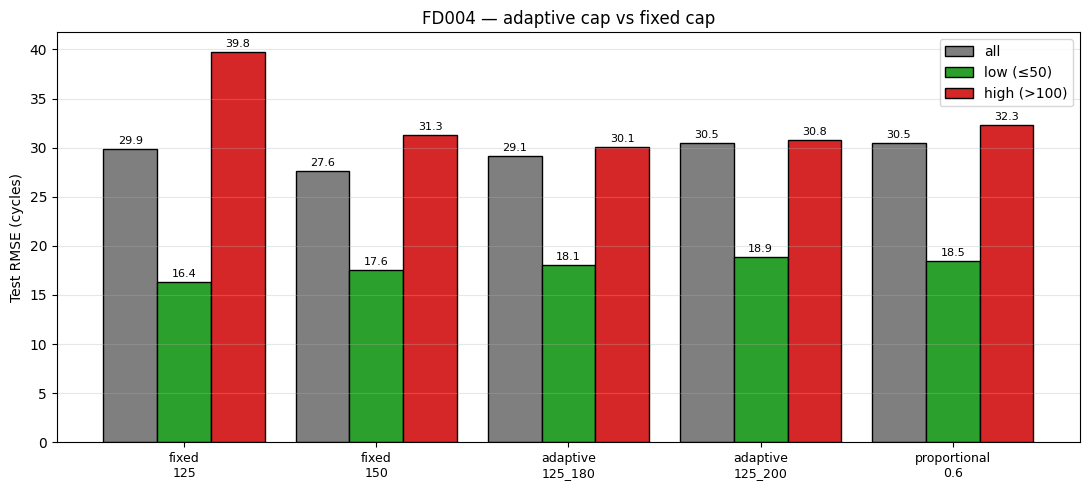

In [9]:
# 60. RMSE by slice, FD004 only, variant comparison
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(variants))
w = 0.28
rmse_all = [r["RMSE_all"] for r in fd004_results]
rmse_low = [r["RMSE_low"] for r in fd004_results]
rmse_high = [r["RMSE_high"] for r in fd004_results]
ax.bar(x - w, rmse_all, w, label="all", color="tab:gray", edgecolor="black")
ax.bar(x, rmse_low, w, label="low (≤50)", color="tab:green", edgecolor="black")
ax.bar(x + w, rmse_high, w, label="high (>100)", color="tab:red", edgecolor="black")
for xi, a, l, h in zip(x, rmse_all, rmse_low, rmse_high):
    for xp, v in [(xi - w, a), (xi, l), (xi + w, h)]:
        ax.text(xp, v + 0.5, f"{v:.1f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([v.replace("_", "\n", 1) for v in variants], fontsize=9)
ax.set_ylabel("Test RMSE (cycles)")
ax.set_title("FD004 — adaptive cap vs fixed cap")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(IMG_DIR / "60_adaptive_cap_rmse.png", bbox_inches="tight")
plt.show()
plt.close()

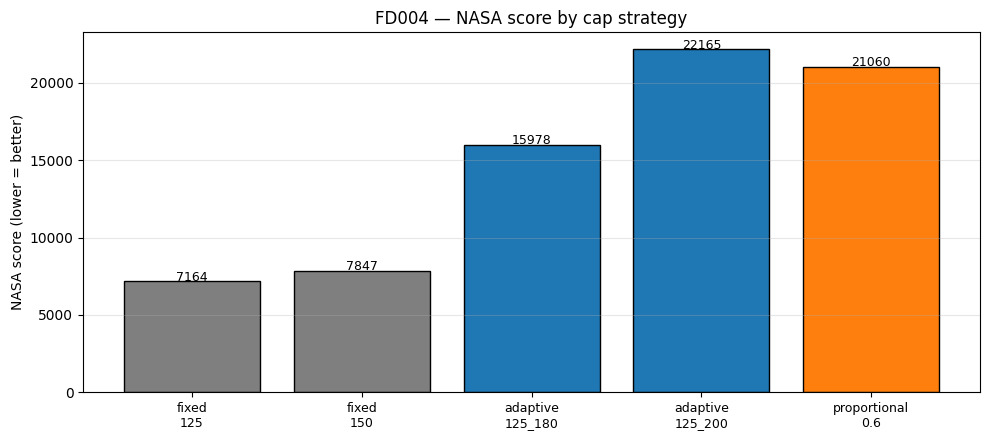

In [10]:
# 61. NASA score comparison
fig, ax = plt.subplots(figsize=(10, 4.5))
nasa_vals = [r["NASA"] for r in fd004_results]
colors = ["tab:gray", "tab:gray", "tab:blue", "tab:blue", "tab:orange"]
bars = ax.bar(x, nasa_vals, color=colors, edgecolor="black")
for xi, v in zip(x, nasa_vals):
    ax.text(xi, v + 50, f"{v:.0f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([v.replace("_", "\n", 1) for v in variants], fontsize=9)
ax.set_ylabel("NASA score (lower = better)")
ax.set_title("FD004 — NASA score by cap strategy")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(IMG_DIR / "61_adaptive_cap_nasa.png", bbox_inches="tight")
plt.show()
plt.close()

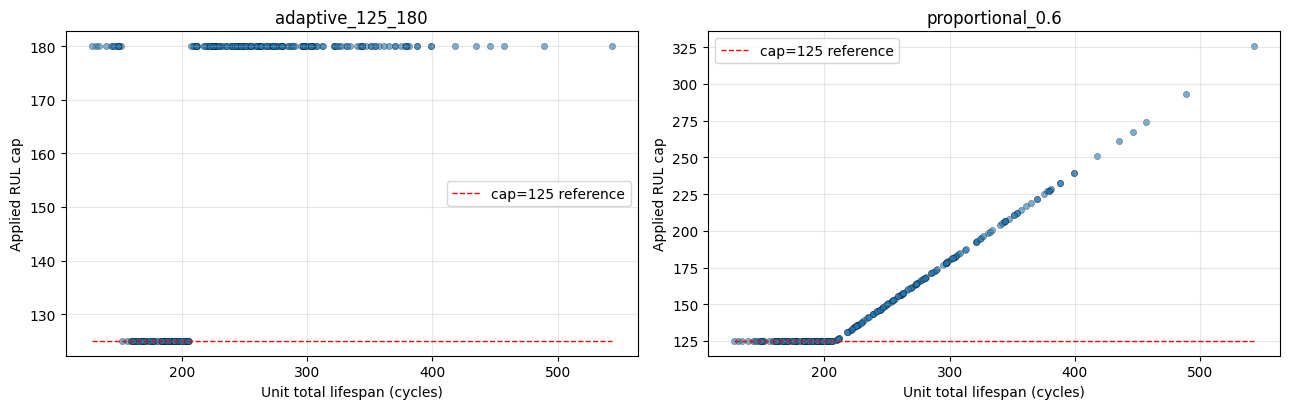

In [11]:
# 62. Cap distribution on training set (adaptive strategies)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, r in zip(axes, [fd004_results[2], fd004_results[4]]):  # adaptive_125_180 + proportional
    lives = train_lives4
    caps_per_unit = r["unit_caps"].values
    ax.scatter(lives, caps_per_unit, alpha=0.6, s=20, edgecolor="black", lw=0.3)
    ax.plot([lives.min(), lives.max()], [125, 125], "r--", lw=1, label="cap=125 reference")
    ax.set_xlabel("Unit total lifespan (cycles)")
    ax.set_ylabel("Applied RUL cap")
    ax.set_title(r["variant"])
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "62_cap_assignment.png", bbox_inches="tight")
plt.show()
plt.close()


Best FD004 variant: fixed_150


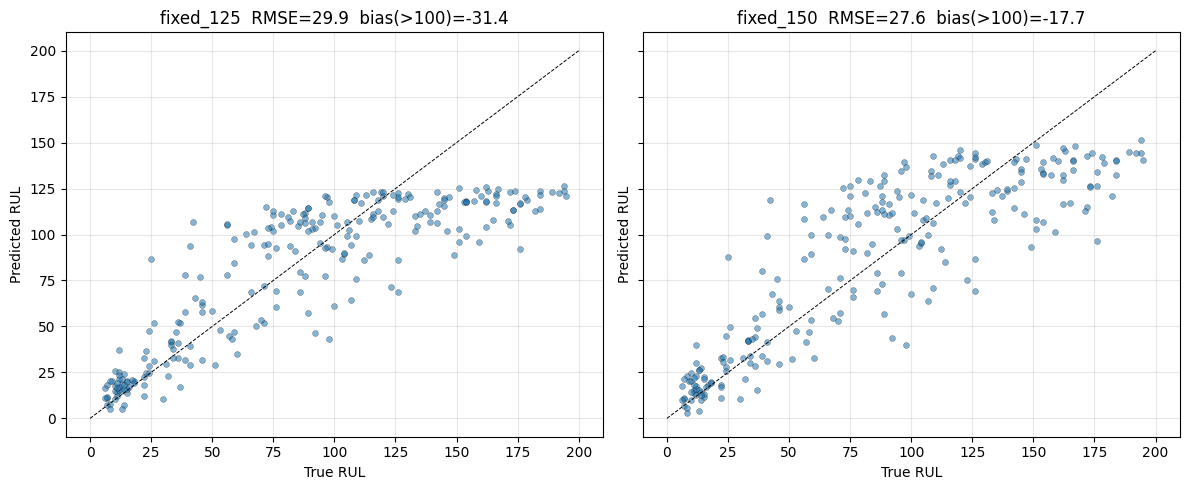

In [12]:
# 63. Scatter: best adaptive vs fixed_125 on FD004
best_idx = int(np.argmin([r["RMSE_all"] for r in fd004_results]))
print(f"\nBest FD004 variant: {fd004_results[best_idx]['variant']}")
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, r in zip(axes, [fd004_results[0], fd004_results[best_idx]]):
    ax.scatter(r["true"], r["preds"], alpha=0.55, s=18, edgecolor="black", lw=0.3)
    lim = max(r["true"].max(), r["preds"].max()) + 5
    ax.plot([0, lim], [0, lim], "k--", lw=0.7)
    ax.set_title(f"{r['variant']}  RMSE={r['RMSE_all']:.1f}  "
                 f"bias(>100)={r['bias_high']:+.1f}")
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Predicted RUL")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "63_fd004_best_vs_baseline.png", bbox_inches="tight")
plt.show()
plt.close()